In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [234]:
import awkward as ak
import numpy as np

from iminuit import minimize
from python.analysis import cross_section, Tags, Plots, Master, vector, SelectionTools, Application, BeamParticleSelection, EventDisplay
from apps.cex_analysis_input import BeamPionSelection
from apps import cex_beam_reweight, cex_analysis_input

cross_section.PlotStyler.SetPlotStyle(extend_colors = True, dpi = 100)

In [3]:
cfg = Application.ApplicationArguments.ResolveConfig(Master.LoadConfiguration("/home/bhuller/work/analysis_new_selection/analysis_config_new_selection.json"))
ntuples = cfg.ntuple_files

In [4]:
samples = {
    "mc" : Master.Data(ntuples["mc"][1]),
    "data" : Master.Data(ntuples["data"][0])
}

In [5]:
samples_mc_beam = cex_analysis_input.BeamPionSelection(samples["mc"] ,cfg, True)

f=<Array [True, True, True, False, ..., False, False, False] type='130635 * bool'>
f=<Array [[True, True, False], ..., [True, ..., False]] type='37507 * var * bool'>


'BeamPionSelection' executed in 7.1409s

In [6]:
reco, true = cex_analysis_input.RegionSelection(samples["mc"], cex_analysis_input.args_to_dict(cfg), True, cfg.region_definitions, cfg.process_definitions, True)

f=<Array [True, True, True, False, ..., False, False, False] type='130635 * bool'>


'RegionSelection' executed in 50.1864s

In [7]:
import copy

true_signal = {k : v for k, v in true.items() if k in ["absorption", "charge_exchange", "pion_production"]}
true_other = {k : v for k, v in true.items() if k in ["impurities", "decay", "escaping",]}

true

{'absorption': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'charge_exchange': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'pion_production': <Array [True, True, True, False, ..., True, True, True] type='37507 * bool'>,
 'impurities': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'decay': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'escaping': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'uncategorised': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>}

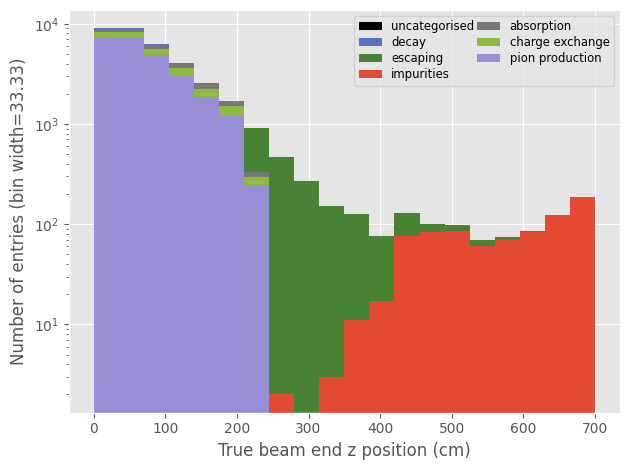

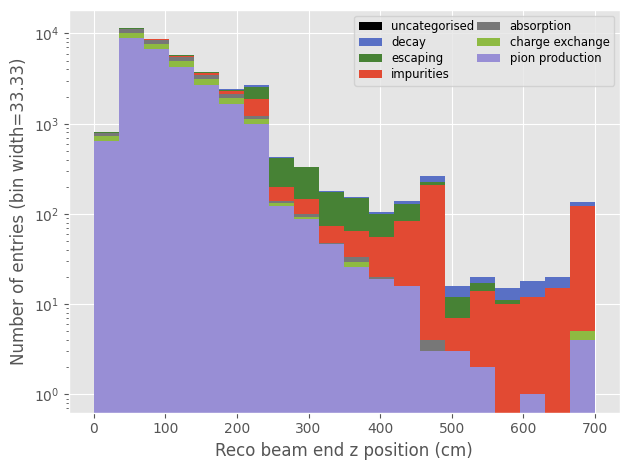

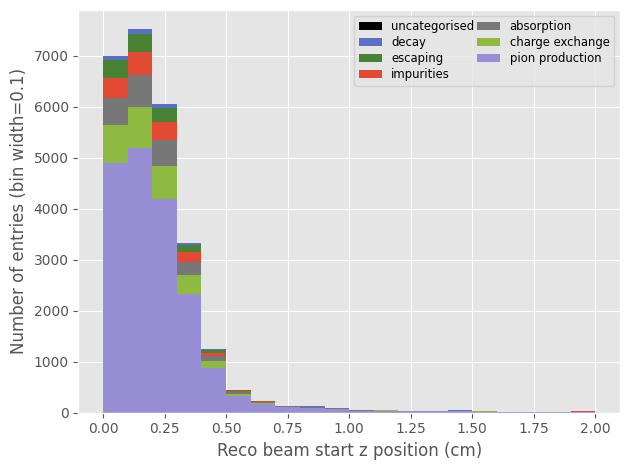

In [8]:
tags = Tags.ExclusiveProcessTags(true)

bins = np.append(np.linspace(0, 220, 11), 700)

Plots.PlotTagged(
    samples_mc_beam.trueParticles.beam_traj_pos.z[:, -1],
    tags, 
    x_label = "True beam end z position (cm)",
    x_range = [0, 700],
    bins = 20,
    norm = False,
    y_scale="log")

Plots.PlotTagged(
    samples_mc_beam.recoParticles.beam_endPos.z,
    tags,
    x_label = "Reco beam end z position (cm)",
    x_range = [0, 700],
    bins = 20,
    norm = False,
    y_scale="log")

Plots.PlotTagged(
    samples_mc_beam.recoParticles.beam_startPos_SCE.z,
    tags,
    x_label = "Reco beam start z position (cm)",
    x_range = [0, 2],
    bins = 20,
    norm = False,
    y_scale="linear")

In [ ]:
large_tracks = (samples_mc_beam.recoParticles.beam_track_length > 220) & (samples_mc_beam.recoParticles.beam_track_length < 450)

In [235]:
truncated_tracks = cross_section.TruncateTrack(samples_mc_beam.recoParticles.beam_calo_pos, z_trunc = 220)
true_truncated_tracks = cross_section.TruncateTrack(samples_mc_beam.trueParticles.beam_traj_pos[samples_mc_beam.trueParticles.in_tpc_z], z_trunc = 220)


In [231]:
def visualise_tracks(mask : ak.Array, n : int = 1, index : int = None, true : bool = False, truncated : bool = False, book : Plots.PlotBook = Plots.PlotBook.null()):
    indices = np.random.choice(range(0, sum(mask)), n)

    if index is not None:
        indices = [index]

    # with Plots.PlotBook("large_tracks_pip.pdf", False) as book:
    for event_index in indices:
        evd = EventDisplay.EventDisplay(samples_mc_beam.eventNum[mask][event_index], "-", "-", plot3D = False)

        # points = samples_mc_beam.recoParticles.beam_calo_pos[mask][event_index]

        if truncated:
            true_tracks = true_truncated_tracks
            reco_tracks = truncated_tracks
        else:
            reco_tracks = samples_mc_beam.recoParticles.beam_calo_pos
            true_tracks = samples_mc_beam.trueParticles.beam_traj_pos

        if true:
            if true_tracks[mask][event_index] is not None:
                evd.PFO(true_tracks[mask][event_index], "o", "r", pointSize=15)
        evd.PFO(reco_tracks[mask][event_index], "o", "k", pointSize=1)
        evd.zx.axvline(220)
        evd.zy.axvline(220)

        evd.zx.set_xlim(left=0)
        evd.zy.set_xlim(left=0)
        book.Save()

    return


In [31]:
reco

{'absorption': <Array [False, False, False, ..., True, False, False] type='37507 * bool'>,
 'charge_exchange': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'pion_production': <Array [True, True, False, False, ..., False, False, True] type='37507 * bool'>,
 'escaping': <Array [False, False, False, ..., False, False, False] type='37507 * bool'>,
 'uncategorised': <Array [False, False, True, True, ..., False, True, False] type='37507 * bool'>}

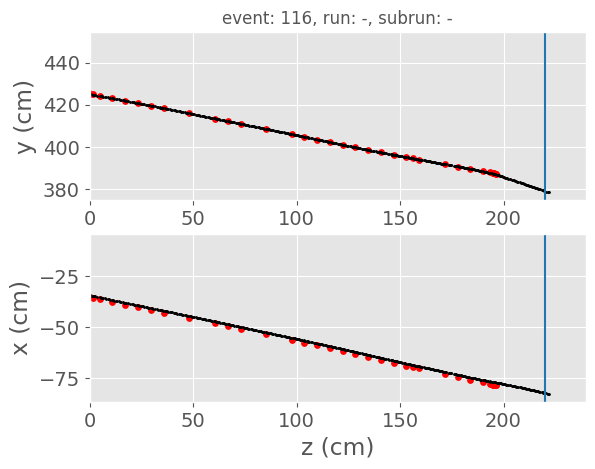

In [67]:
mask = large_tracks & reco["escaping"] #& true["pion_production"]

visualise_tracks(mask, 1, true = True)

In [236]:
def track_fit(tracks):
    gradients = vector.prod(
    1 / ak.num(tracks, 1),
    vector.sub(tracks[:, -1], tracks[:, 0]))

    exp = vector.add(vector.prod(ak.local_index(tracks), gradients), tracks[:, 0])
    chi2 = vector.multiply(vector.reciprocal(exp), vector.power(vector.sub(tracks, exp), 2))
    ndf = ak.num(tracks, 1)

    chi2 = vector.prod(1/ndf, vector.vector(**{i : abs(ak.sum(chi2[i], -1)) for i in chi2.fields}))
    return chi2

chi2 = track_fit(truncated_tracks)

(0.0, 1.0)

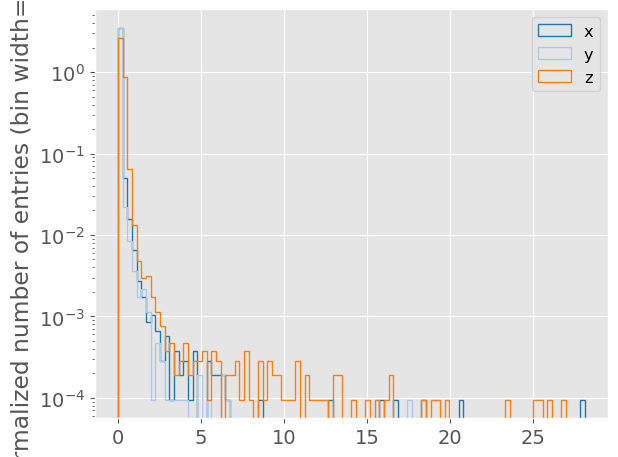

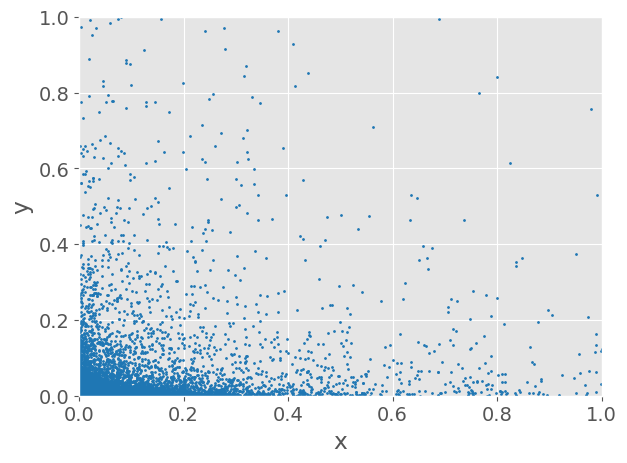

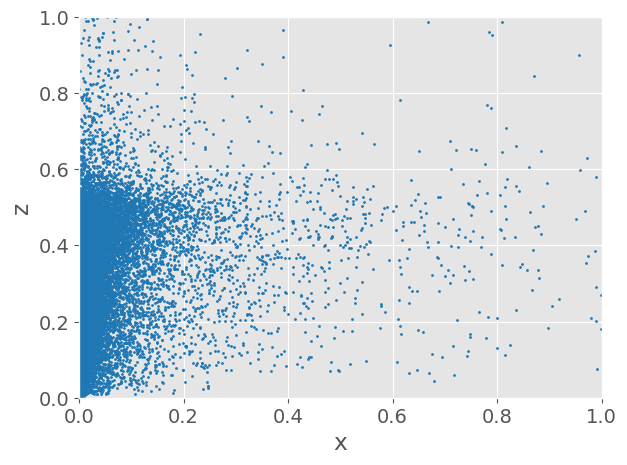

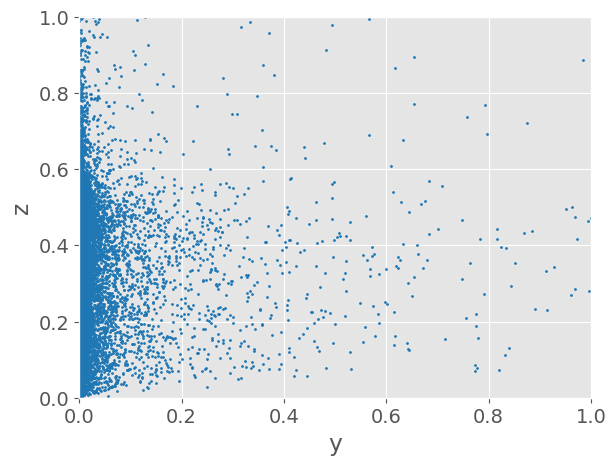

In [71]:
Plots.PlotHistComparison([chi2.x, chi2.y, chi2.z], ["x", "y", "z"], y_scale = "log")

Plots.Plot(chi2.x, chi2.y, marker = "o", markersize = 1, linestyle = "", xlabel = "x", ylabel = "y")
Plots.plt.xlim(0, 1)
Plots.plt.ylim(0, 1)

Plots.Plot(chi2.x, chi2.z, marker = "o", markersize = 1, linestyle = "", xlabel = "x", ylabel = "z")
Plots.plt.xlim(0, 1)
Plots.plt.ylim(0, 1)

Plots.Plot(chi2.y, chi2.z, marker = "o", markersize = 1, linestyle = "", xlabel = "y", ylabel = "z")
Plots.plt.xlim(0, 1)
Plots.plt.ylim(0, 1)



In [237]:
pitch = cross_section.TrackPitch(truncated_tracks)

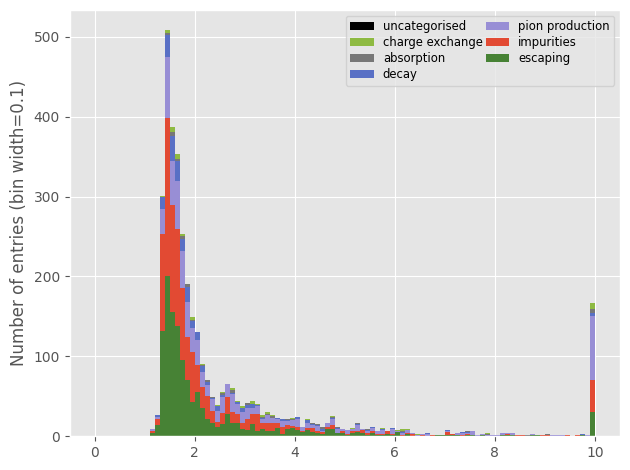

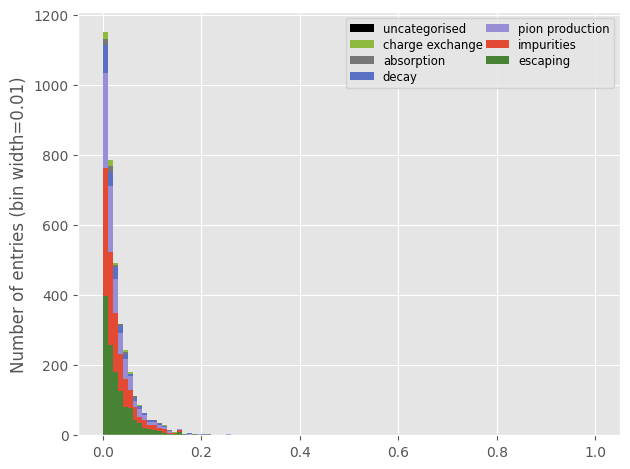

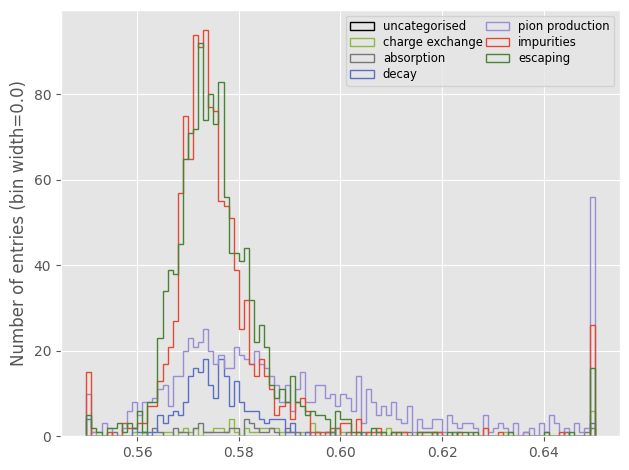

In [278]:
updated_tags = Tags.ExclusiveProcessTags({k : v & reco["escaping"] for k, v in true.items()})

Plots.PlotTagged(ak.max(pitch, -1), updated_tags, y_scale="linear", x_range=[0, 10], truncate = True)

Plots.PlotTagged(ak.min(pitch, -1), updated_tags, y_scale="linear", x_range=[0, 1], truncate = True)

Plots.PlotTagged(ak.mean(pitch, axis=-1), updated_tags, y_scale="linear", x_range=[0.55, 0.65], truncate = True, stacked=False, histtype="step")


In [73]:
truncated_track_length = cross_section.TrackLength(tracks = truncated_tracks)

cross_section.TrackLength(tracks = truncated_tracks)
any(ak.is_none(cross_section.TrackLength(pitches = pitch)))

False

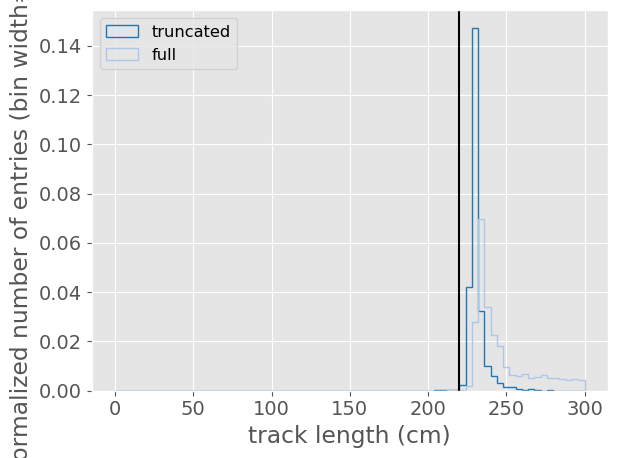

In [74]:
Plots.PlotHistComparison([truncated_track_length[reco["escaping"]], samples_mc_beam.recoParticles.beam_track_length[reco["escaping"]]], bins = 75, labels = ["truncated", "full"], x_range = [0, 300], xlabel = "track length (cm)")
Plots.plt.axvline(220, color = "k")

In [ ]:

traj_KE = samples_mc_beam.trueParticles.beam_traj_KE[samples_mc_beam.trueParticles.in_tpc_z]
end_KE_true_trunc = traj_KE[ak.local_index(traj_KE) == (ak.num(true_truncated_tracks)-2)]
end_KE_true_trunc = ak.ravel(ak.fill_none(ak.pad_none(end_KE_true_trunc, 1, -1), 0, None))

end_KE_true = samples_mc_beam.trueParticles.beam_traj_KE[:, -2]

In [128]:
outside_tpc = ~ak.any(samples_mc_beam.trueParticles.in_tpc_z, -1)

# samples_mc_beam.trueParticles.beam_track_length[outside_tpc]
true_truncated_tracks[outside_tpc]
samples_mc_beam.trueParticles.beam_traj_KE[samples_mc_beam.trueParticles.in_tpc_z]

<Array [[1.7e+03, 1.7e+03, ..., 1.35e+03, 0], ...] type='37507 * var * float64'>

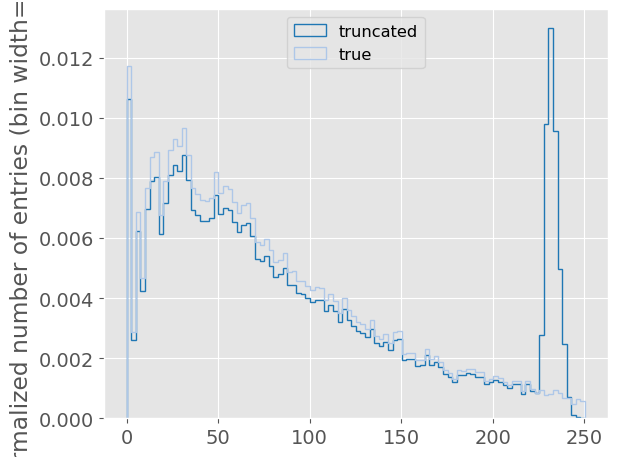

In [129]:

trunc_track_len_true = cross_section.TrackLength(tracks=true_truncated_tracks)

samples_mc_beam.trueParticles.beam_track_length
Plots.PlotHistComparison([trunc_track_len_true, samples_mc_beam.trueParticles.beam_track_length], ["truncated", "true"])


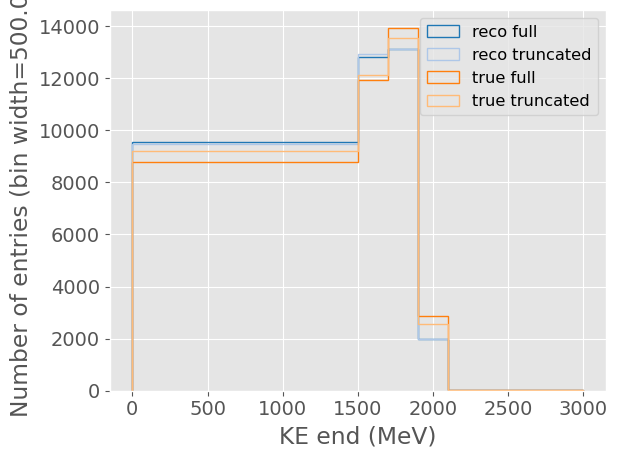

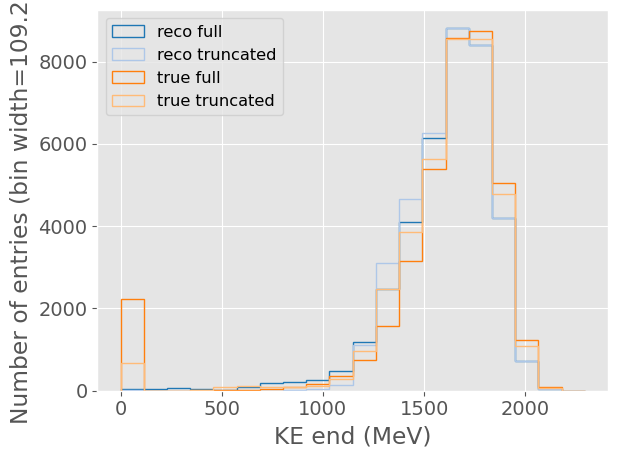

In [130]:
reco_KE_inst = cross_section.KE(samples_mc_beam.recoParticles.beam_inst_P, cross_section.Particle.from_pdgid(211).mass)
reco_upstream_loss = cross_section.UpstreamEnergyLoss(reco_KE_inst, cfg.upstream_loss_correction_params["value"], cfg.upstream_loss_response)

zero_energy = end_KE_true_trunc == 0


samples_mc_beam.trueParticles.beam_traj_KE[zero_energy]


# true_truncated_tracks[zero_energy] cfg.upstream_loss_correction_params["value"], cfg.upstream_loss_response)
reco_KE_ff = reco_KE_inst - reco_upstream_loss

# KE_end_full = cross_section.BetheBloch.InteractingKE(reco_KE_ff, samples_mc_beam.recoParticles.beam_track_length, 50)
KE_end_full = cross_section.RecoEndEnergy(samples_mc_beam.recoParticles.beam_calo_pos, reco_KE_ff, None, method = "track")

# KE_end = cross_section.BetheBloch.InteractingKE(reco_KE_ff, truncated_track_length, 50)
KE_end = cross_section.RecoEndEnergy(truncated_tracks, reco_KE_ff, None, method = "track")

mask = reco["escaping"] & (~true["impurities"]) & (~true["decay"])

bins = [[0, 1500, 1700, 1900, 2100, 3000], 20]
for b in bins:
    Plots.PlotHistComparison([KE_end_full, KE_end, end_KE_true, end_KE_true_trunc], labels = ["reco full", "reco truncated", "true full", "true truncated"], xlabel = "KE end (MeV)", density = False, bins = b)

pdf /home/bhuller/KE_end_all.pdf has been opened
pdf /home/bhuller/KE_end_all.pdf has been closed
pdf /home/bhuller/KE_end_pions.pdf has been opened
pdf /home/bhuller/KE_end_pions.pdf has been closed


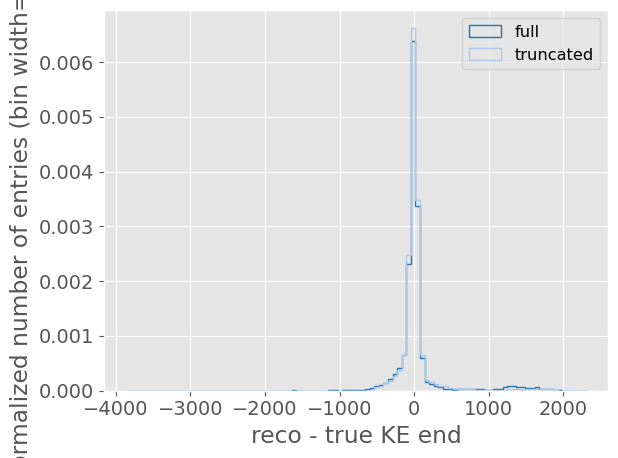

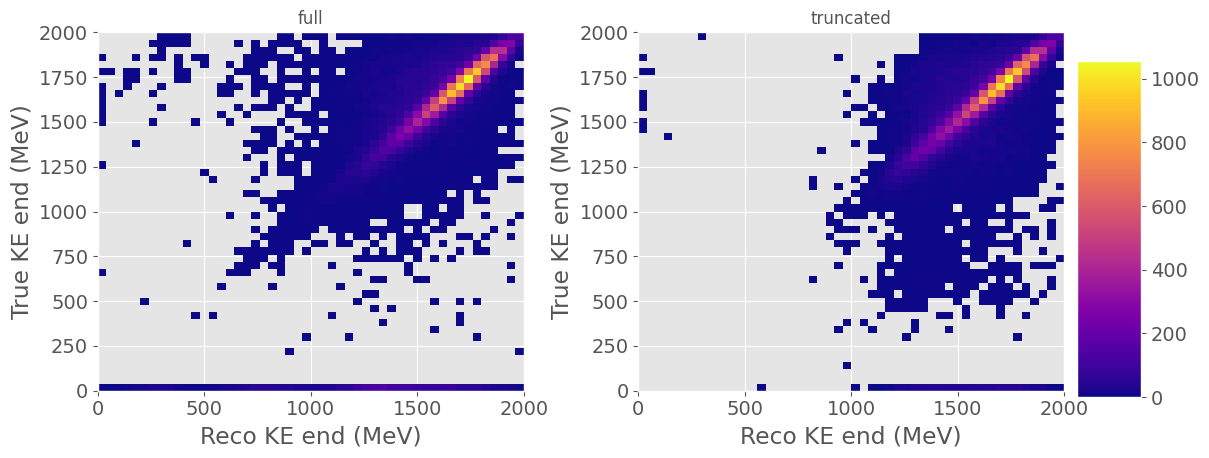

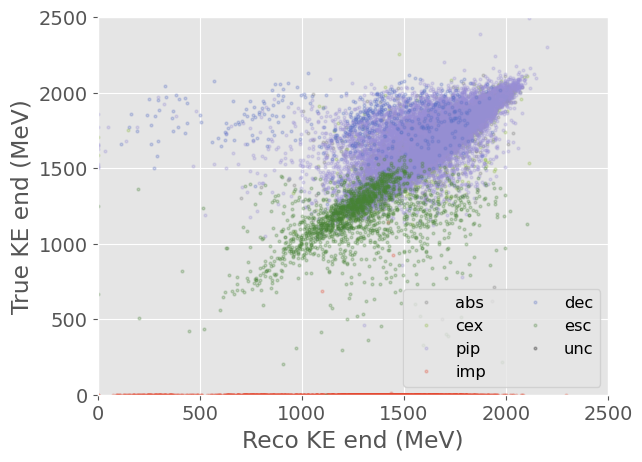

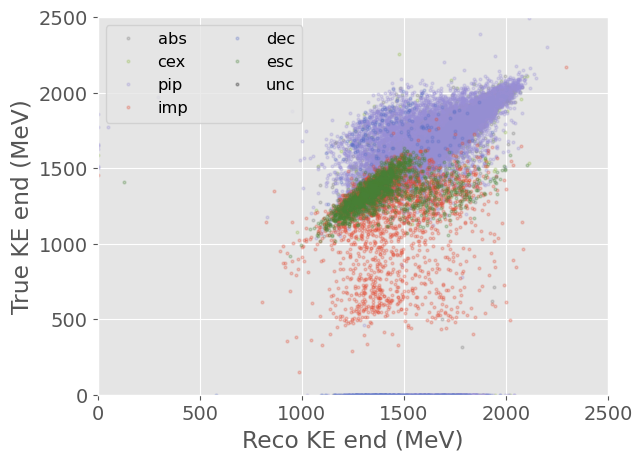

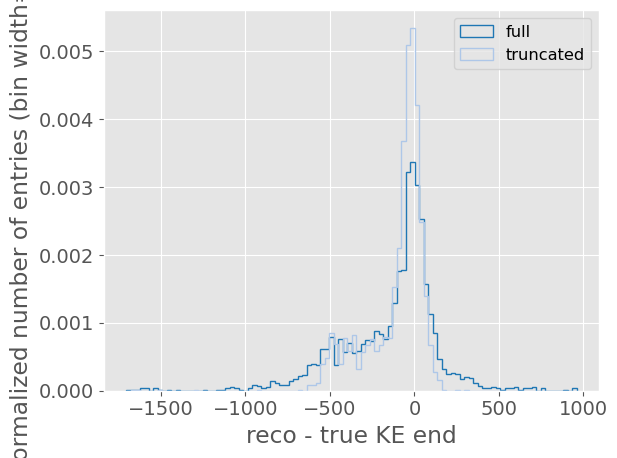

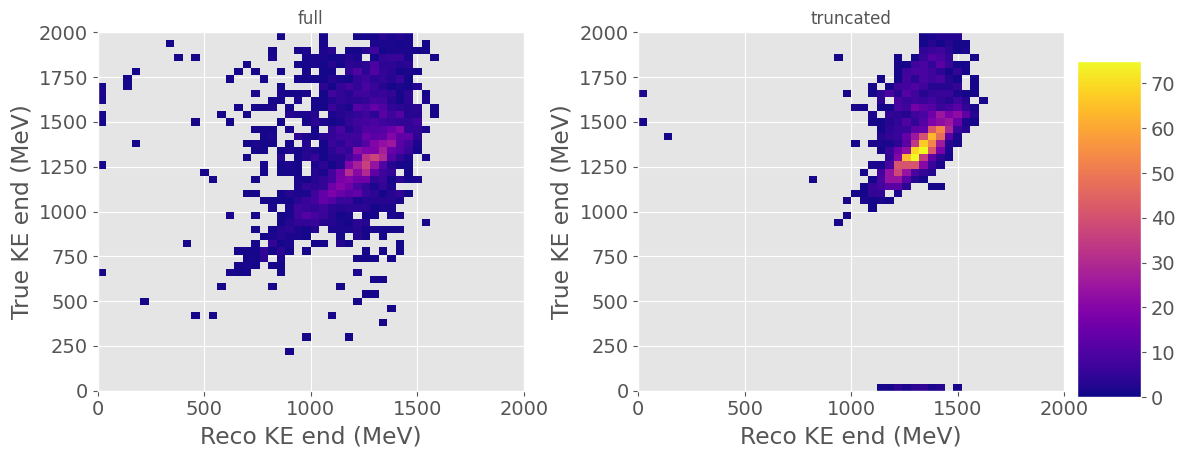

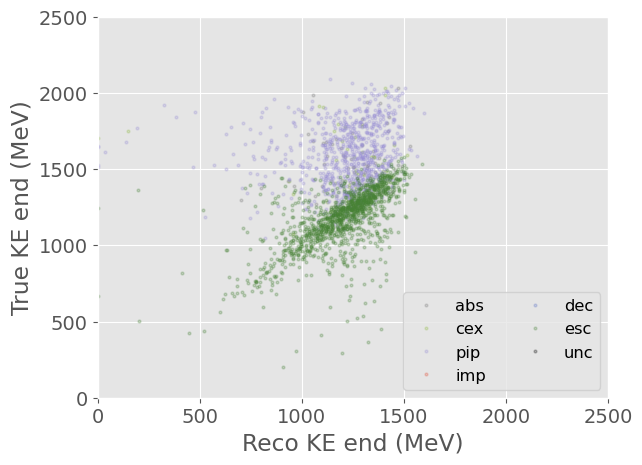

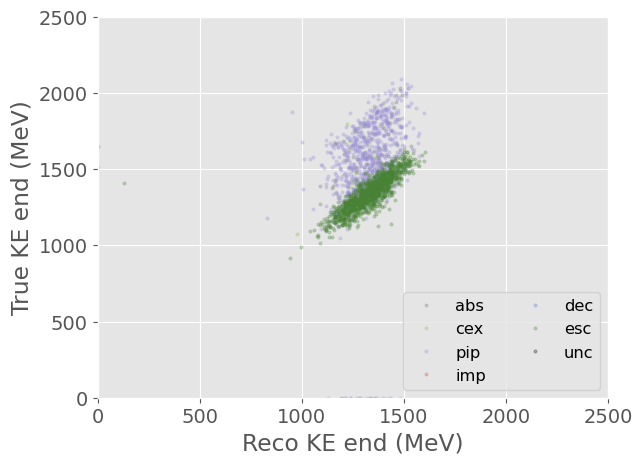

In [131]:
def scatter(x, y, mask = None):
    Plots.plt.figure()
    for t in tags:
        if mask is not None:
            m = tags[t].mask & mask
        else:
            m = tags[t].mask
        Plots.Plot(np.array(x)[m], np.array(y)[m], marker="o", markersize=2, linestyle="", label=tags[t].name_simple, color = tags[t].colour, newFigure = False, xlabel = "Reco KE end (MeV)", ylabel = "True KE end (MeV)", alpha = 0.25)
    Plots.plt.legend(ncols=2)
    Plots.plt.xlim(0, 2500)
    Plots.plt.ylim(0, 2500)
    return

def plot_KE_res(mask = None, book : Plots.PlotBook = Plots.PlotBook.null()):
    if mask is None:
        mask = ak.ones_like(KE_res, dtype = bool)

    Plots.PlotHistComparison([(KE_res[mask]), (KE_res_trunc[mask])], ["full", "truncated"], xlabel = "reco - true KE end")
    book.Save()
    Plots.PlotHist2DComparison([np.array(KE_end_full[mask]), np.array(KE_end[mask])], [np.array(end_KE_true[mask]), np.array(end_KE_true_trunc[mask])], x_range = [0, 2000], y_range = [0, 2000], xlabels = ["Reco KE end (MeV)"]*2, ylabels = ["True KE end (MeV)"]*2, titles = ["full", "truncated"])
    book.Save()
    scatter(KE_end_full, end_KE_true, mask)
    book.Save()
    scatter(KE_end, end_KE_true_trunc, mask)
    book.Save()

    return

KE_res = KE_end_full - end_KE_true
KE_res_trunc = KE_end - end_KE_true_trunc

# cut = mean_chi2 < 0.125

# Plots.PlotHistComparison([(KE_res)[mask], (KE_res_trunc)[mask]], ["full", "truncated"], xlabel = "reco - true KE end")
# Plots.PlotHist2DComparison([np.array(KE_end_full[mask]), np.array(KE_end[mask])], [np.array(end_KE[mask]), np.array(end_KE_trunc[mask])], x_range = [0, 2000], y_range = [0, 2000], xlabels = ["Reco KE end (MeV)"]*2, ylabels = ["True KE end (MeV)"]*2, titles = ["full", "truncated"])

# Plots.PlotHistComparison([(KE_res)[mask & cut], (KE_res_trunc)[mask & cut]], ["full", "truncated"], xlabel = "reco - true KE end")
# Plots.PlotHist2DComparison([np.array(KE_end_full[mask & cut]), np.array(KE_end[mask & cut])], [np.array(end_KE[mask & cut]), np.array(end_KE_trunc[mask & cut])], x_range = [0, 2000], y_range = [0, 2000], xlabels = ["Reco KE end (MeV)"]*2, ylabels = ["True KE end (MeV)"]*2, titles = ["full", "truncated"])

with Plots.PlotBook("/home/bhuller/KE_end_all.pdf", True) as book:
    plot_KE_res(book = book)

with Plots.PlotBook("/home/bhuller/KE_end_pions.pdf", True) as book:
    plot_KE_res(mask, book)


pdf /home/bhuller/track_length_check.pdf has been opened
pdf /home/bhuller/track_length_check.pdf has been closed


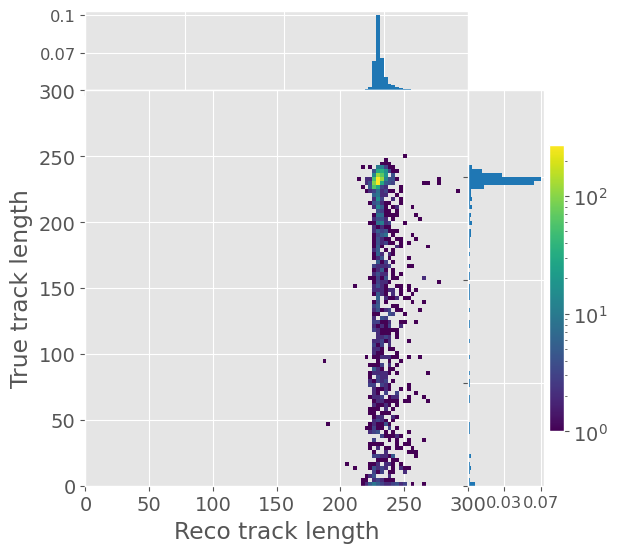

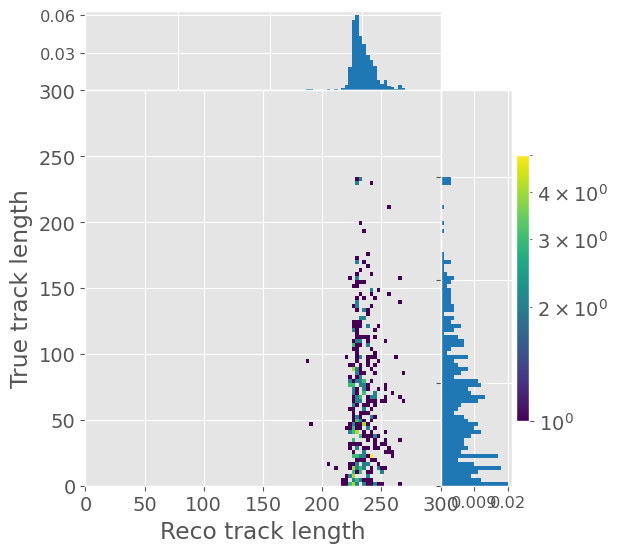

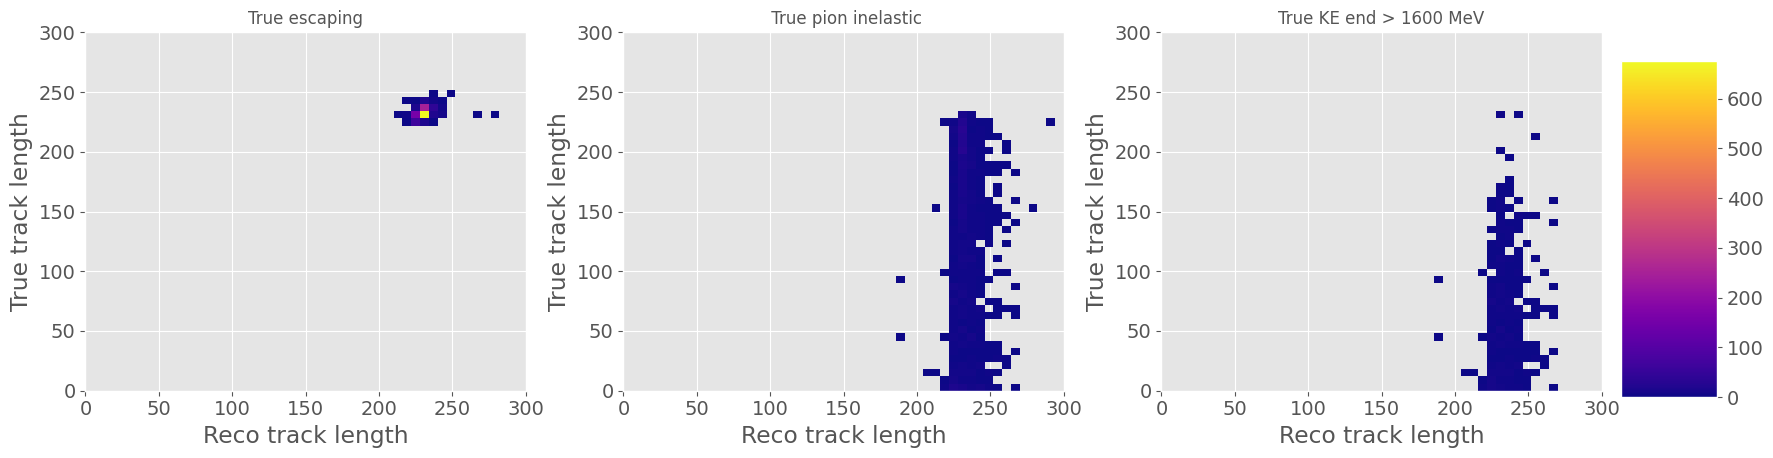

In [159]:
with Plots.PlotBook("/home/bhuller/track_length_check", True) as book:
    Plots.PlotHist2DMarginal(truncated_track_length[mask], trunc_track_len_true[mask], x_range=[0, 300], y_range=[0, 300], ylabel = "True track length", xlabel = "Reco track length")
    book.Save()
    Plots.PlotHist2DMarginal(truncated_track_length[mask & (end_KE_true_trunc > 1600)], trunc_track_len_true[mask & (end_KE_true_trunc > 1600)], x_range=[0, 300], y_range=[0, 300], ylabel = "True track length", xlabel = "Reco track length")
    book.Save()
    tmp_mask = true["pion_production"] | true["charge_exchange"] | true["absorption"]
    energy_mask = end_KE_true_trunc > 1600
    Plots.PlotHist2DComparison([np.array(truncated_track_length[mask & true["escaping"]]), np.array(truncated_track_length[mask & tmp_mask]), np.array(truncated_track_length[mask & energy_mask])], [np.array(trunc_track_len_true[mask & true["escaping"]]), np.array(trunc_track_len_true[mask & tmp_mask]), np.array(trunc_track_len_true[mask & energy_mask])], x_range = [0, 300], y_range = [0, 300], xlabels = ["Reco track length"]*3, ylabels = ["True track length"]*3, titles = ["True escaping", " True pion inelastic", "True KE end > 1600 MeV"])
    book.Save()


index=55
KE_res_trunc[vis_mask][index]=np.float64(-229.466704573691)
end_KE_true_trunc[vis_mask][index]=np.float64(1494.247358074157)
KE_end[vis_mask][index]=np.float64(1264.780653500466)
pdf truncated_tracks_escaping_inel.pdf has been opened


/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis/python/analysis/EventDisplay.py:56: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  self.fig2D, (self.zy, self.zx) = plt.subplots(nrows=2, ncols=1, figsize=(6.4*20, 4.8*20), num=1)


pdf truncated_tracks_escaping_inel.pdf has been closed


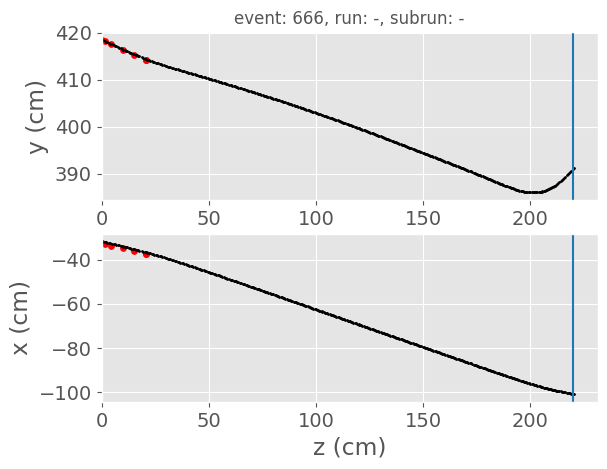

In [233]:

vis_mask = mask & tmp_mask
index = np.random.choice(ak.sum(vis_mask))
print(f"{index=}")
print(f"{KE_res_trunc[vis_mask][index]=}")
print(f"{end_KE_true_trunc[vis_mask][index]=}")
print(f"{KE_end[vis_mask][index]=}")

with Plots.PlotBook("truncated_tracks_escaping_inel.pdf", True) as book:
    visualise_tracks(vis_mask, 50, true = True, index = None, truncated = True, book = book)

(array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 2., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        ...,
        [2., 6., 1., ..., 1., 0., 0.],
        [3., 3., 3., ..., 0., 0., 0.],
        [2., 1., 4., ..., 0., 0., 0.]], shape=(100, 100)),
 [array([-250., -245., -240., -235., -230., -225., -220., -215., -210.,
         -205., -200., -195., -190., -185., -180., -175., -170., -165.,
         -160., -155., -150., -145., -140., -135., -130., -125., -120.,
         -115., -110., -105., -100.,  -95.,  -90.,  -85.,  -80.,  -75.,
          -70.,  -65.,  -60.,  -55.,  -50.,  -45.,  -40.,  -35.,  -30.,
          -25.,  -20.,  -15.,  -10.,   -5.,    0.,    5.,   10.,   15.,
           20.,   25.,   30.,   35.,   40.,   45.,   50.,   55.,   60.,
           65.,   70.,   75.,   80.,   85.,   90.,   95.,  100.,  105.,
          110.,  115.,  120.,  125.,  130.,  135.,  140.,  145.,  150.,
          155.,  160.,  165.,  170.,  175.,  180.,  185.,  190.,  195.,
          200

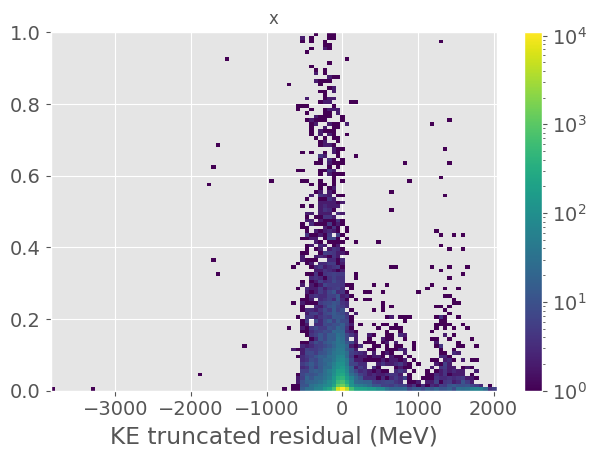

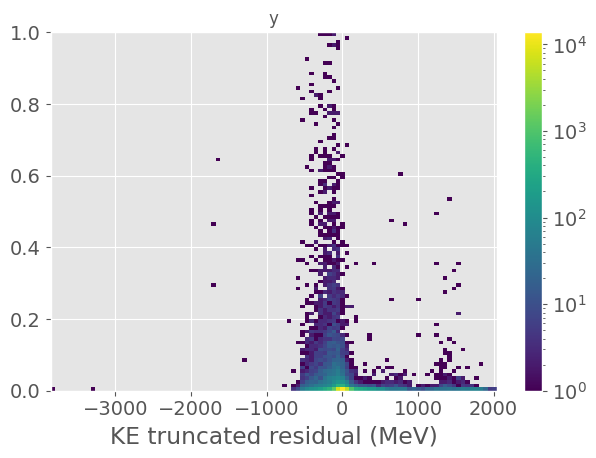

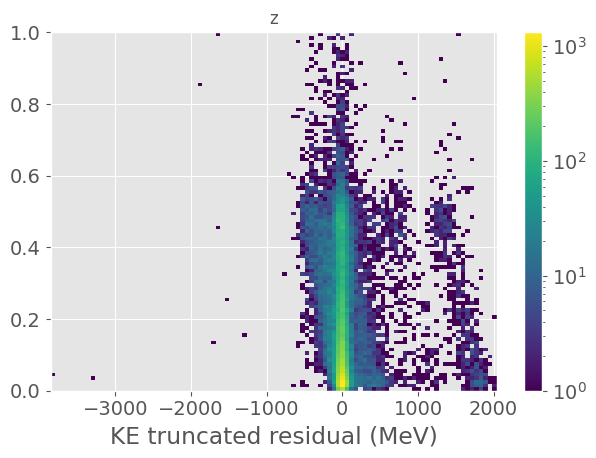

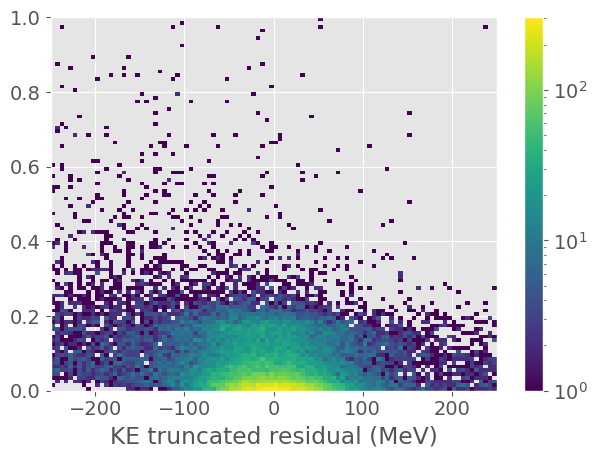

In [26]:
for i in chi2.fields:
    # Plots.PlotHist2D(KE_res[mask], chi2[i][mask], y_range=[0, 5], xlabel = "KE residual (MeV)", title = i)
    Plots.PlotHist2D(KE_res_trunc, chi2[i], y_range=[0, 1], xlabel = "KE truncated residual (MeV)", title = i)

mean_chi2 = (chi2.x + chi2.y + chi2.z)/3

Plots.PlotHist2D(KE_res_trunc, mean_chi2, xlabel = "KE truncated residual (MeV)", y_range = [0, 1], x_range = [-250, 250])

ak.sum(mask)=np.int64(159)
index=20
chi2.x[mask][index]=np.float64(0.7891076350759699)
chi2.y[mask][index]=np.float64(0.0657219338066771)
chi2.z[mask][index]=np.float64(29.859671295993735)
KE_res_trunc[mask][index]=np.float64(-39.72375944070791)


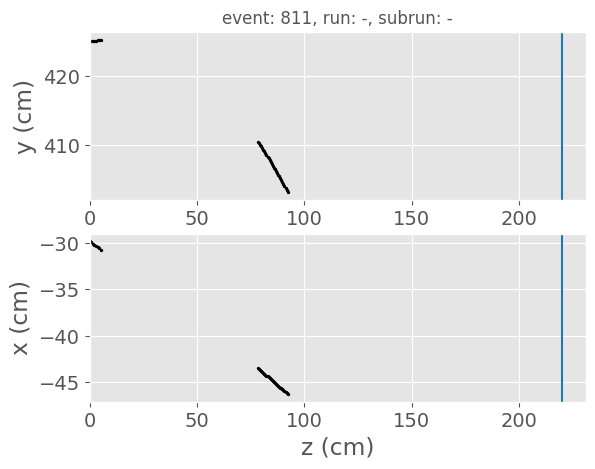

In [24]:
mask = (mean_chi2 > 0.5) & (abs(KE_res_trunc) < 150)

print(f"{ak.sum(mask)=}")
index = np.random.choice(ak.sum(mask))
print(f"{index=}")
print(f"{chi2.x[mask][index]=}")
print(f"{chi2.y[mask][index]=}")
print(f"{chi2.z[mask][index]=}")
print(f"{KE_res_trunc[mask][index]=}")

visualise_tracks(mask, 1, true = False, index = index)

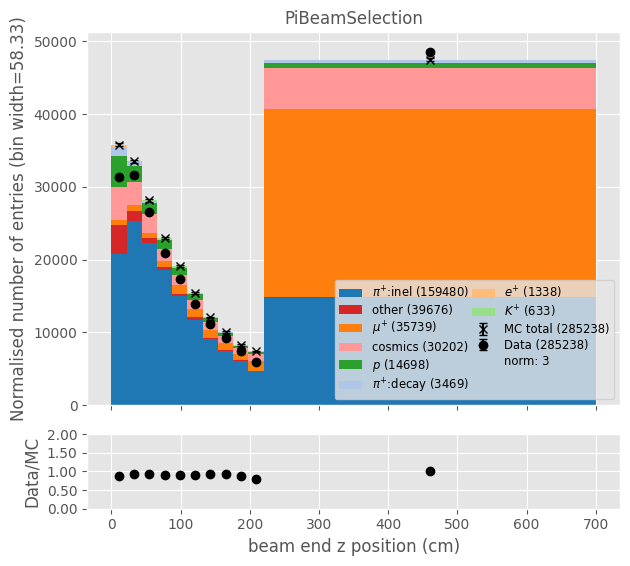

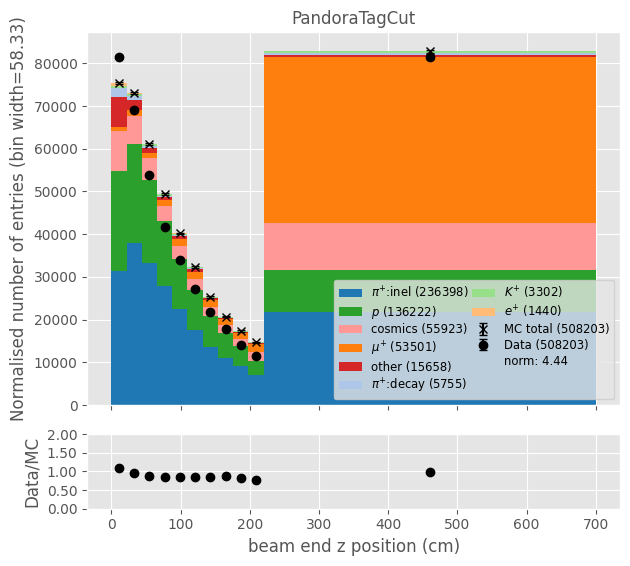

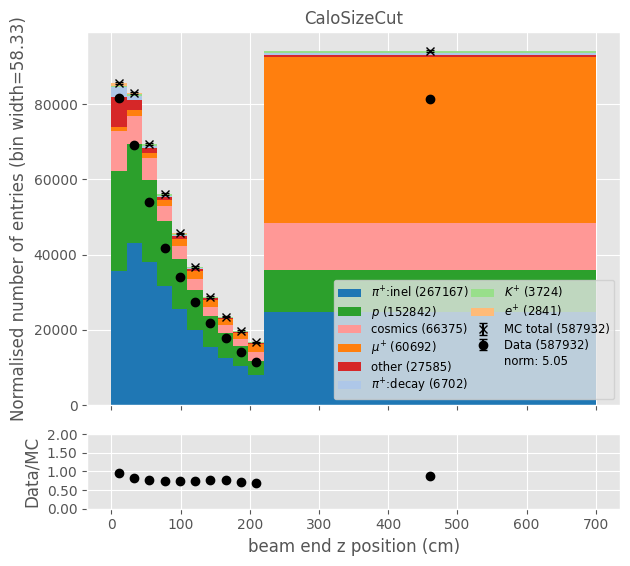

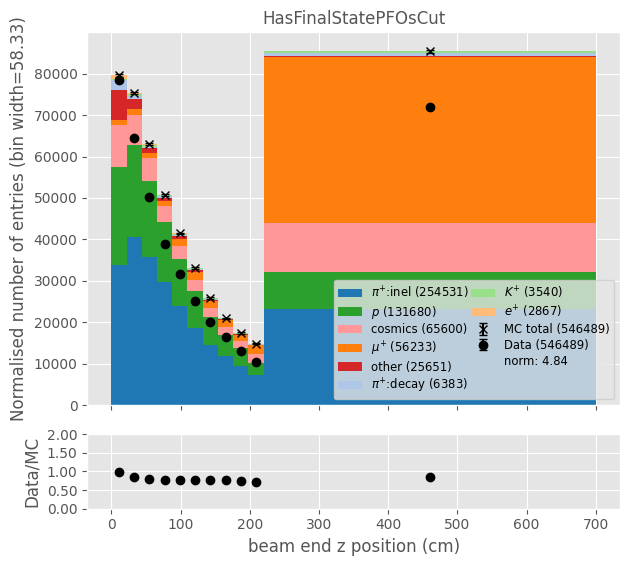

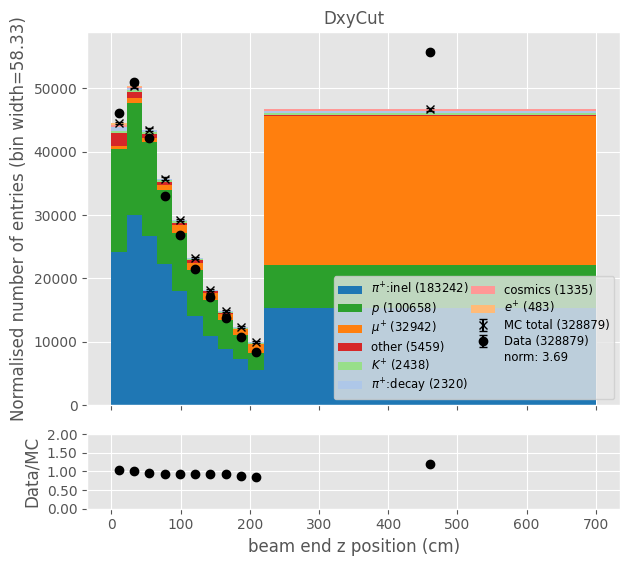

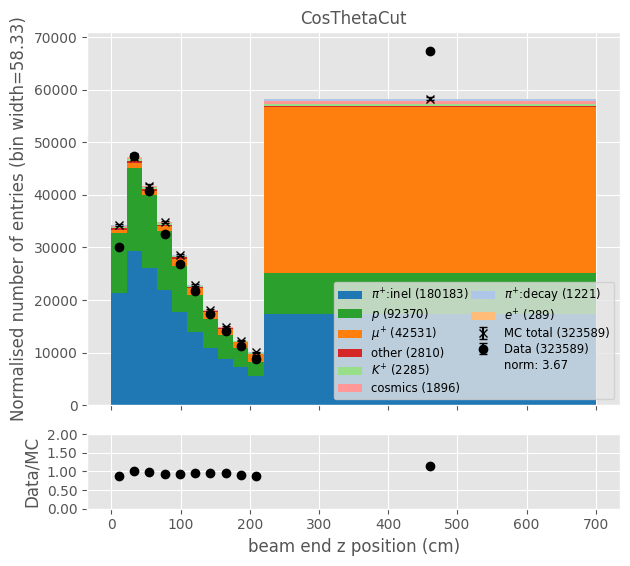

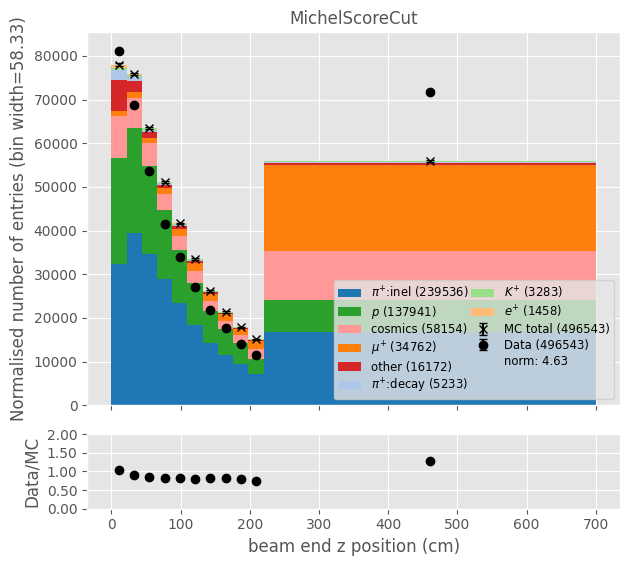

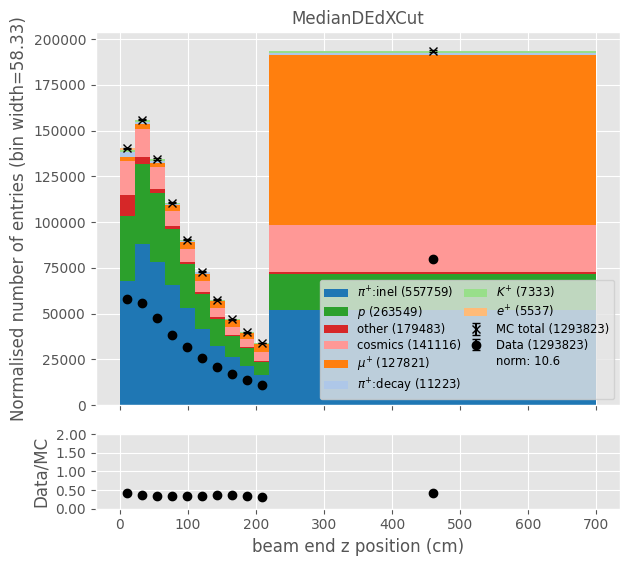

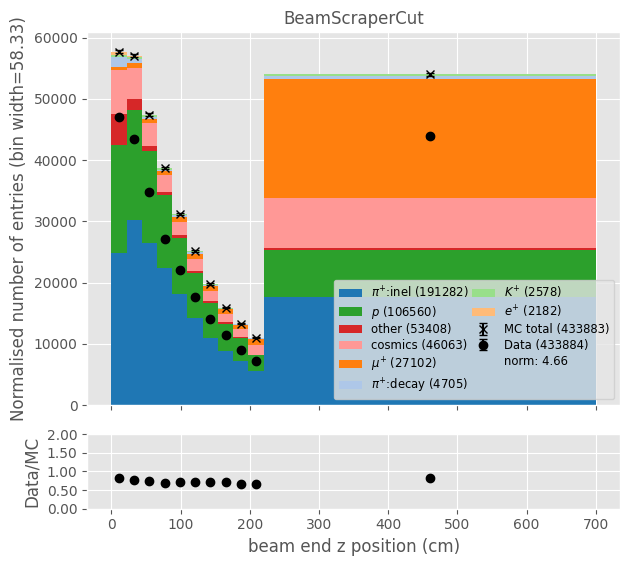

In [5]:
masks_mc = cfg.selection_masks["mc"]["beam"][samples["mc"].filename]
masks_data = cfg.selection_masks["data"]["beam"][samples["data"].filename]

z_pos_mc = samples["mc"].recoParticles.beam_endPos_SCE.z
z_pos_data = samples["data"].recoParticles.beam_endPos_SCE.z

tags = cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"])

bins = np.append(np.linspace(0, 220, 11), 700)

def update_tags(mask):
    new_tags = cross_section.copy.deepcopy(tags)
    for k in new_tags.keys():
        new_tags[k].mask = new_tags[k].mask[mask]
    return new_tags


for (k, vm), vd in zip(masks_mc.items(), masks_data.values()):
    Plots.PlotTagged(z_pos_mc[vm], update_tags(vm), data2 = z_pos_data[vd], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True, title = k)


# cfg.selection_masks["data"]["beam"][samples["data"].filename]

pdf end_z.pdf has been opened
pdf end_z.pdf has been closed


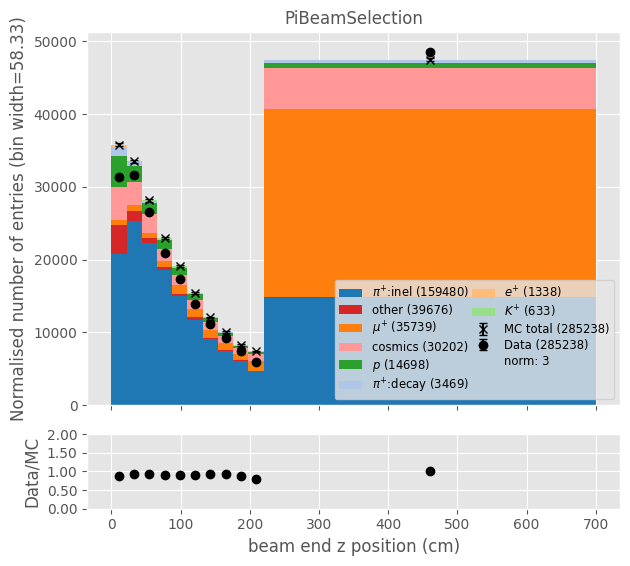

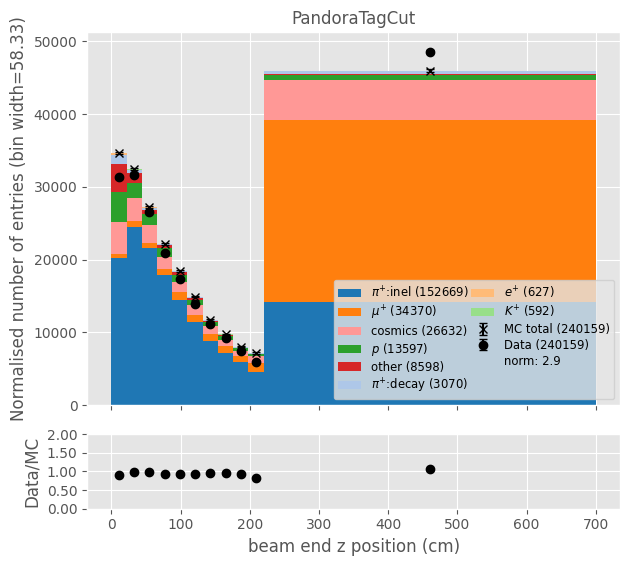

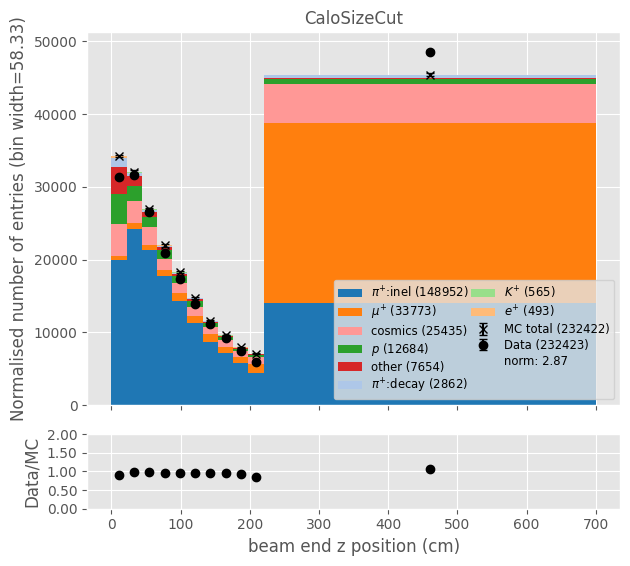

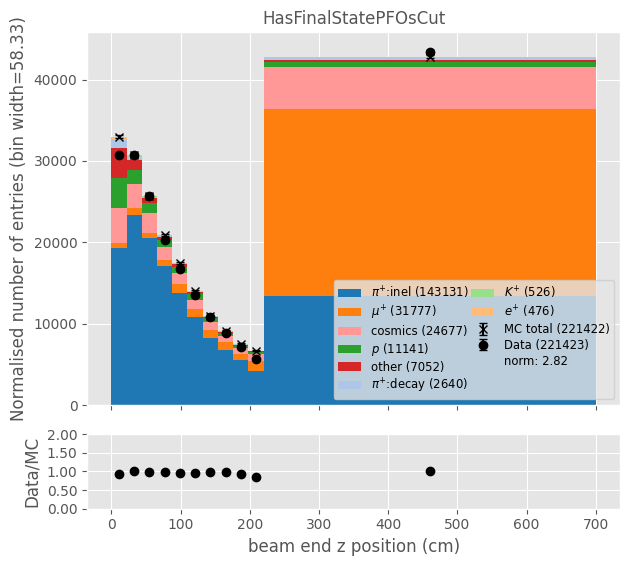

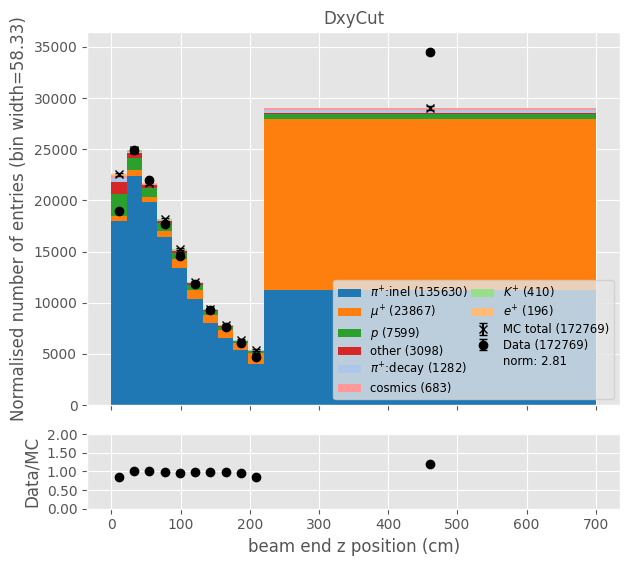

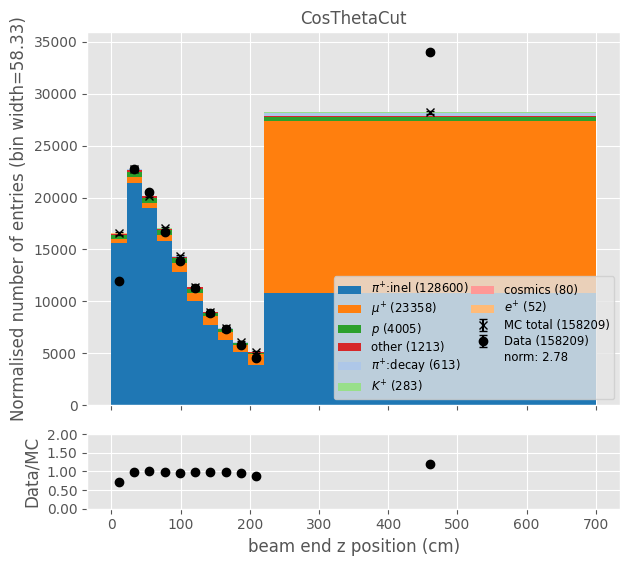

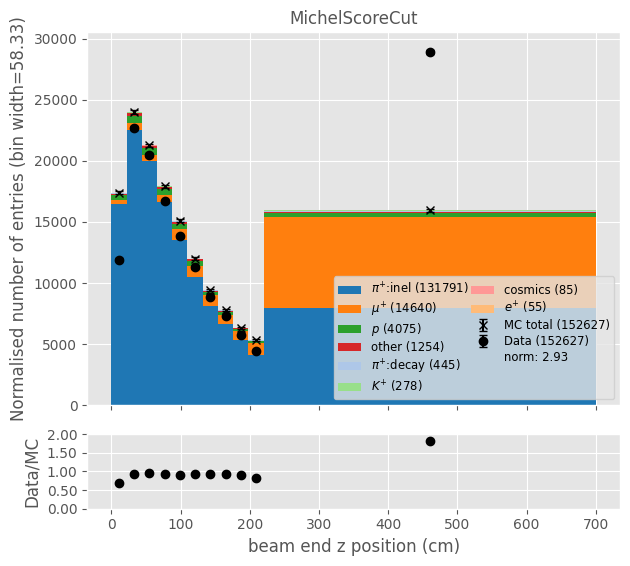

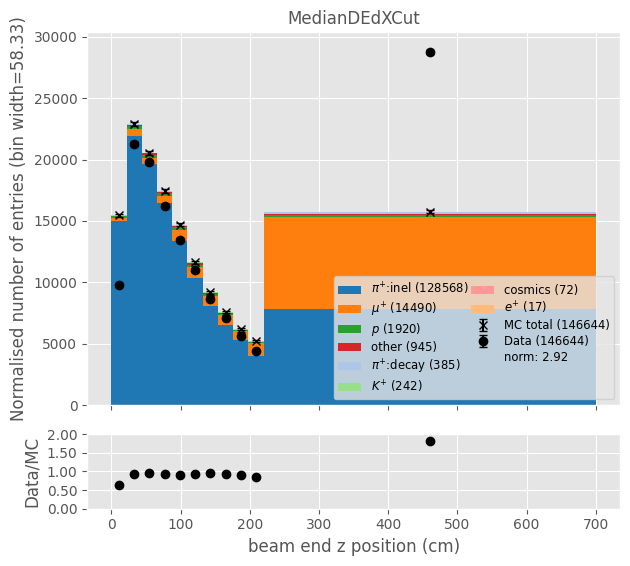

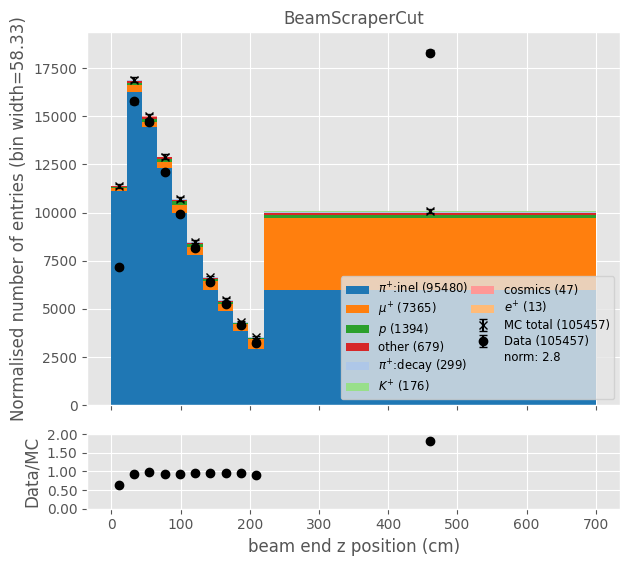

In [11]:
masks_mc = cfg.selection_masks["mc"]["beam"][samples["mc"].filename]
masks_data = cfg.selection_masks["data"]["beam"][samples["data"].filename]

z_pos_mc = samples["mc"].recoParticles.beam_endPos_SCE.z
z_pos_data = samples["data"].recoParticles.beam_endPos_SCE.z

tags = cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"])

bins = np.append(np.linspace(0, 220, 11), 700)

def update_tags(mask):
    new_tags = cross_section.copy.deepcopy(tags)
    for k in new_tags.keys():
        new_tags[k].mask = new_tags[k].mask[mask]
    return new_tags

def update_mask(current, new):
    if current is None:
        current = new
    else:
        current = current & new
    return current

current_mask_data = None
current_mask_mc = None
with Plots.PlotBook("end_z") as book:
    for (k, vm), vd in zip(masks_mc.items(), masks_data.values()):
        current_mask_mc = update_mask(current_mask_mc, vm)
        current_mask_data = update_mask(current_mask_data, vd)
        Plots.PlotTagged(z_pos_mc[current_mask_mc], update_tags(current_mask_mc), data2 = z_pos_data[current_mask_data], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True, title = k)
        book.Save()


In [5]:
mask = samples["data"].recoParticles.beam_inst_valid
mask = mask & (samples["data"].recoParticles.beam_inst_trigger != 8)
mask = mask & (samples["data"].recoParticles.beam_inst_nTracks == 1) & (samples["data"].recoParticles.beam_inst_nMomenta == 1)
mask = mask & samples["data"].recoParticles.reco_reconstructable_beam_event


In [ ]:
book = Plots.PlotBook("sideband_study", False)

pdf sideband_study.pdf has been opened


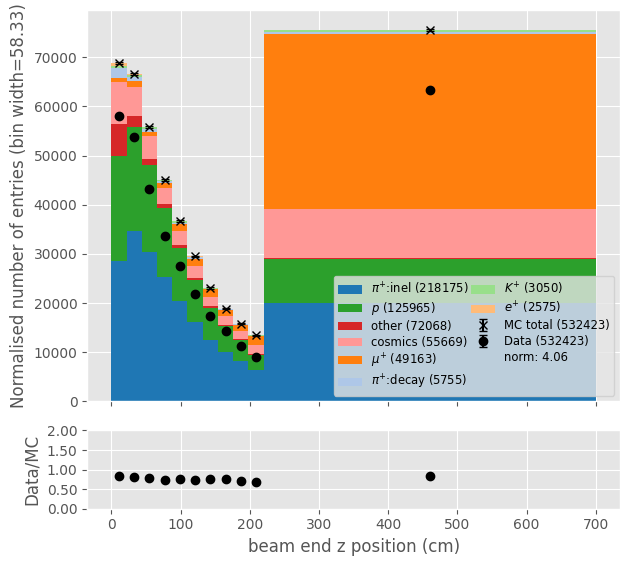

In [56]:
# Plots.PlotTagged(samples["mc"].recoParticles.beam_inst_P, cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_inst_P[mask], x_range = [1500, 2500], bins = 50, norm = True)
# book.Save()

bins = np.append(np.linspace(0, 220, 11), 700)

Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, cross_section.Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_label = "beam end z position (cm)", x_range = [0, 700], bins = bins, norm = True)
# book.Save()

In [10]:
# Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_range = [0, 100], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)
# Plots.PlotTagged(samples["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_endPos_SCE.z[mask], x_range = [0, 100], y_scale = "log", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)

# Plots.PlotTagged(samples["mc"].recoParticles.beam_michelScore, Tags.GenerateTrueBeamParticleTags(samples["mc"]), data2 = samples["data"].recoParticles.beam_michelScore[mask], x_range = [0, 1], y_scale = "linear", truncate = True, x_label = "michel_score", norm = True, bins = 50)

In [27]:
beam_proton = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [2212], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [2212], True)
    }
beam_pion = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [211, 13, -13], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [211, 13, -13], True)
    }


In [57]:
def z_pos(mask):
    selected_sample = {k : v.Filter([mask[k]], [mask[k]], returnCopy = True) for k, v in samples.items()}

    return {k : v.recoParticles.beam_endPos_SCE.z for k, v in selected_sample.items()}, Tags.GenerateTrueBeamParticleTags(selected_sample["mc"])

def beam_pos(mask):
    selected_sample = {k : v.Filter([mask[k]], [mask[k]], returnCopy = True) for k, v in samples.items()}

    return {k : v.recoParticles.beam_inst_P for k, v in selected_sample.items()}, Tags.GenerateTrueBeamParticleTags(selected_sample["mc"])

def plot_z(z, tags, weights = None):
    Plots.PlotTagged(z["mc"], tags, data2 = z["data"], x_range = [0, 700], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = bins, data_weights = weights)
    return

f=<Array [False, True, True, True, ..., False, True, True] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>
f=<Array [True, False, False, ..., True, False, False] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


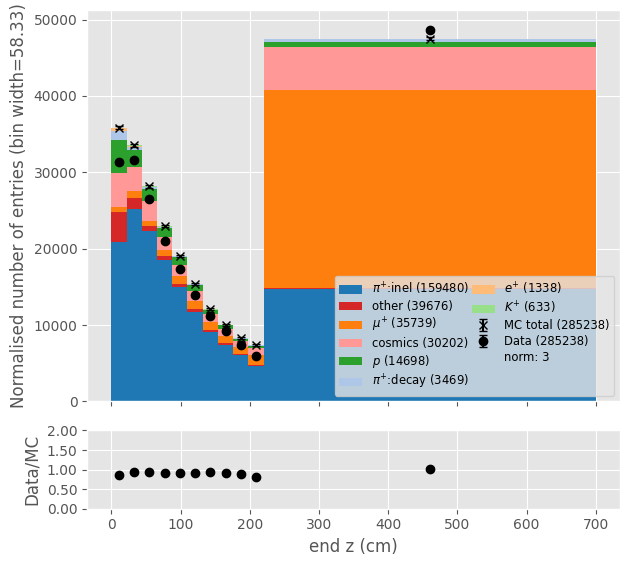

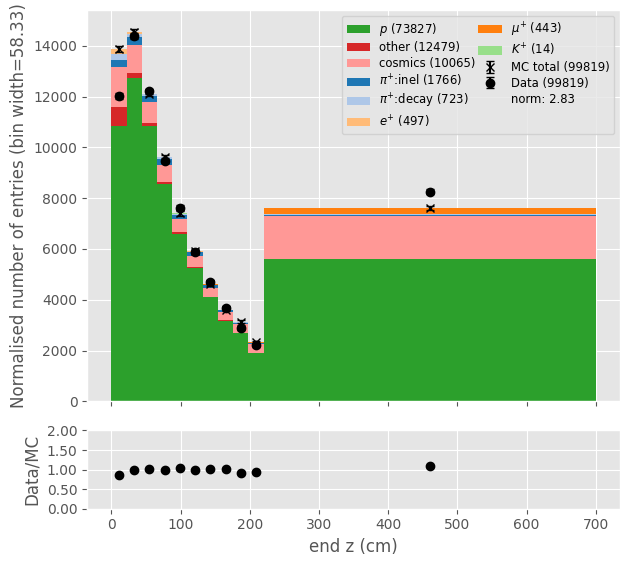

In [58]:
z_pion = z_pos(beam_pion)
z_proton = z_pos(beam_proton)

plot_z(*z_pion)
book.Save()
plot_z(*z_proton)
book.Save()

# z = {k : v[beam_proton[k]] for k, v in z.items()}
# Plots.PlotTagged(z["mc"], Tags.GenerateTrueBeamParticleTags(selected_sample["mc"]), data2 = z["data"], x_range = [0, 700], y_scale = "linear", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)
# Plots.PlotTagged(z["mc"], Tags.GenerateTrueBeamParticleTags(selected_sample["mc"]), data2 = z["data"], x_range = [0, 700], y_scale = "log", truncate = False, x_label = "end z (cm)", norm = True, bins = 50)


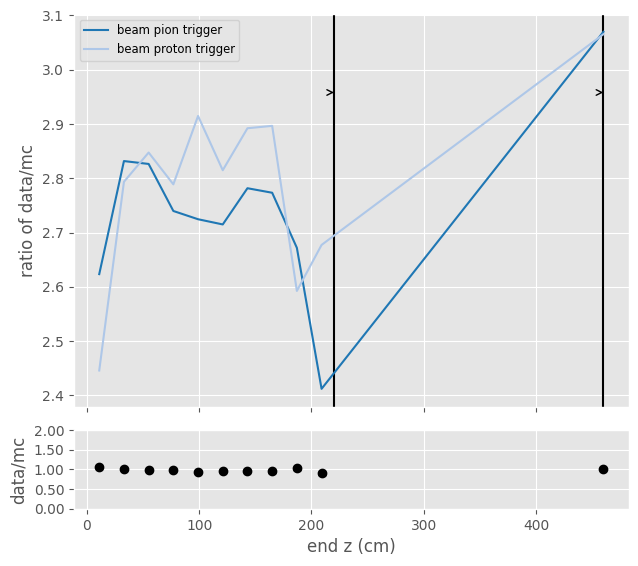

In [60]:
# bins = np.arange(0, 700, 14)
bins = np.append(np.linspace(0, 220, 11), 700)


def ratio(z):

    mc = np.histogram(z[0]["mc"], bins)[0]
    data = np.histogram(z[0]["data"], bins)[0]
    r = data / mc
    delta_r = r * (1/mc + 1/data)**0.5

    return r, delta_r

r_pion = ratio(z_pion)
r_proton = ratio(z_proton)


with Plots.RatioPlot(cross_section.bin_centers(bins), r_pion[0], r_proton[0], r_pion[1], r_proton[1], xlabel = "end z (cm)", ylabel = "data/mc") as rplot:
    Plots.Plot(rplot.x, rplot.y1, label = "beam pion trigger", ylabel = "ratio of data/mc", newFigure = False)
    Plots.Plot(rplot.x, rplot.y2, label = "beam proton trigger", newFigure = False)
    Plots.DrawCutPosition(220)
    Plots.DrawCutPosition(460)
book.Save()
# z_pion["data"] / z_pion["mc"]

In [15]:
def step_func_mask(x, boundaries, operators):
    masks = []
    for b, o in zip(boundaries, operators):
        masks.append(cross_section.SelectionTools.cuts_to_func(b, o)(x))

    return masks

def step_func(x, step, boundaries, operators):
    values = np.zeros_like(x)
    for s, b, o in zip(step, boundaries, operators):
        mask = cross_section.SelectionTools.cuts_to_func(b, o)(x)
        values = np.where(mask, s, values)
    return values

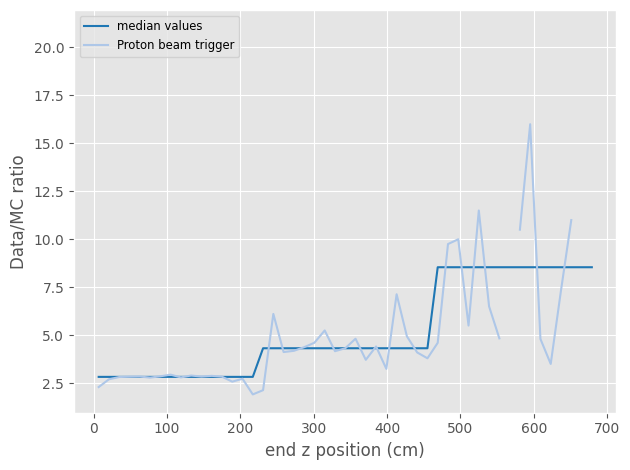

In [38]:
x = rplot.x
ratio = rplot.y2
isf = np.isfinite(ratio)


boundaries = [220, [220, 460], 460]
operators  = ["<", [">=", "<="], ">"]

masks = step_func_mask(x[isf], boundaries, operators)
sf = [np.nanmedian(ratio[isf][m]) for m in masks]

y = step_func(x, sf, boundaries, operators)

Plots.Plot(x, y, xlabel = "end z position (cm)", ylabel = "Data/MC ratio", label = "median values")
Plots.Plot(rplot.x, rplot.y2, label = "Proton beam trigger", newFigure = False)
book.Save()

In [44]:
[i/proton_ratio for i in sf]

[np.float64(0.999361172588429),
 np.float64(1.5273893366040152),
 np.float64(3.021788186617778)]

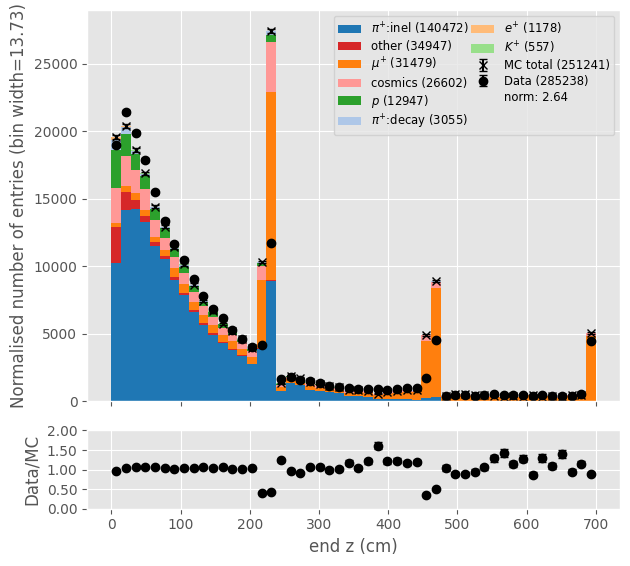

In [39]:
proton_ratio = len(z_proton[0]["data"]) / len(z_proton[0]["mc"])
y = step_func(z_pion[0]["mc"], sf, boundaries, operators) / proton_ratio

# plot_z(*z_pion)
plot_z(*z_pion, weights = y)
book.Save()

f=<Array [False, True, True, True, ..., False, True, True] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


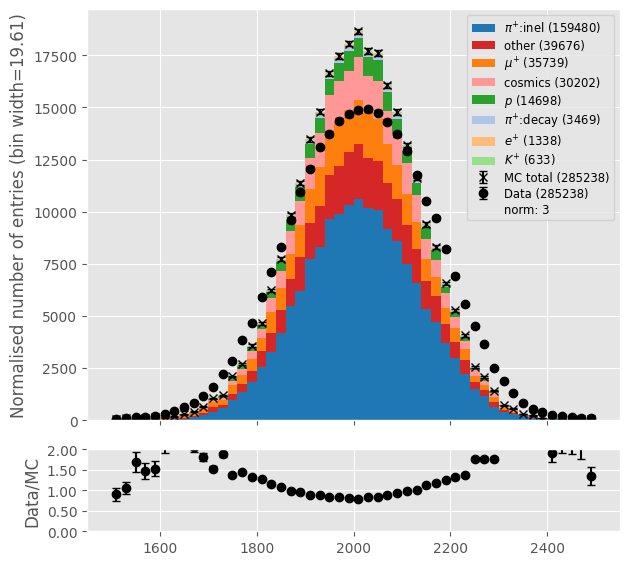

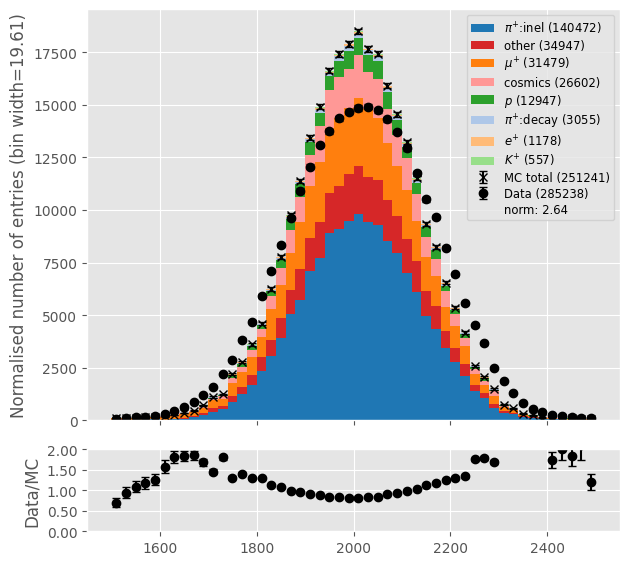

In [40]:
beam_p_pion = beam_pos(beam_pion)
Plots.PlotTagged(beam_p_pion[0]["mc"], beam_p_pion[1], data2 = beam_p_pion[0]["data"], x_range = [1500, 2500], bins = 50, norm = True, ncols = 1)
book.Save()
Plots.PlotTagged(beam_p_pion[0]["mc"], beam_p_pion[1], data2 = beam_p_pion[0]["data"], x_range = [1500, 2500], bins = 50, norm = True, data_weights = y, ncols = 1)
book.Save()

In [41]:
book.close()

pdf sideband_study.pdf has been closed


# Proton

In [24]:
beam_trigger_selection = {
    "mc" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["mc"], [2212], False),
    "data" : cross_section.BeamParticleSelection.BeamTriggerSelection(samples["data"], [2212], True)
    }

proton_sample = {k : v.Filter([beam_trigger_selection[k]], [beam_trigger_selection[k]], returnCopy = True) for k, v in samples.items()}


f=<Array [True, False, False, ..., True, False, False] type='131266 * bool'>
f=<Array [False, False, False, ..., False, False, False] type='1349399 * bool'>


In [25]:
# normalisation 
n_data = ak.sum(beam_trigger_selection["data"])
n_mc = ak.sum(beam_trigger_selection["mc"])
norm = round(n_data / n_mc, 3)
print(norm)

2.827


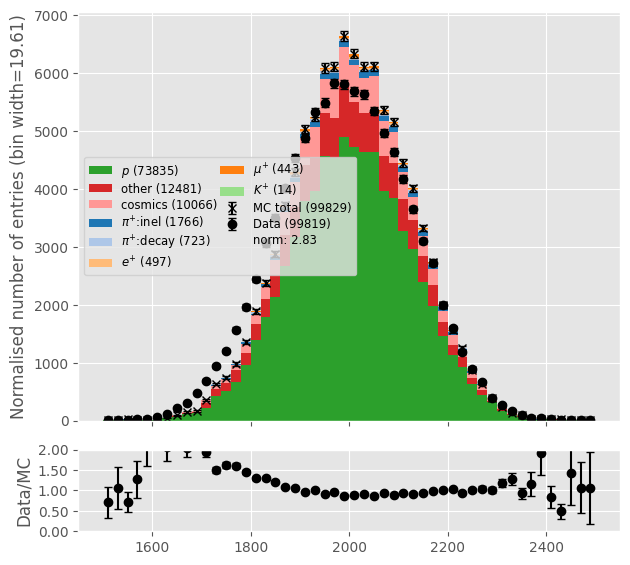

In [26]:
Plots.PlotTagged(proton_sample["mc"].recoParticles.beam_inst_P, cross_section.Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.beam_inst_P, x_range = [1500, 2500], bins = 50, norm = norm)

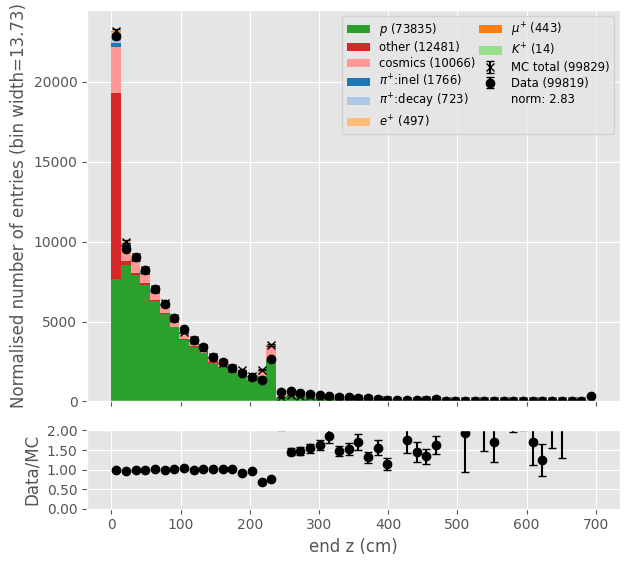

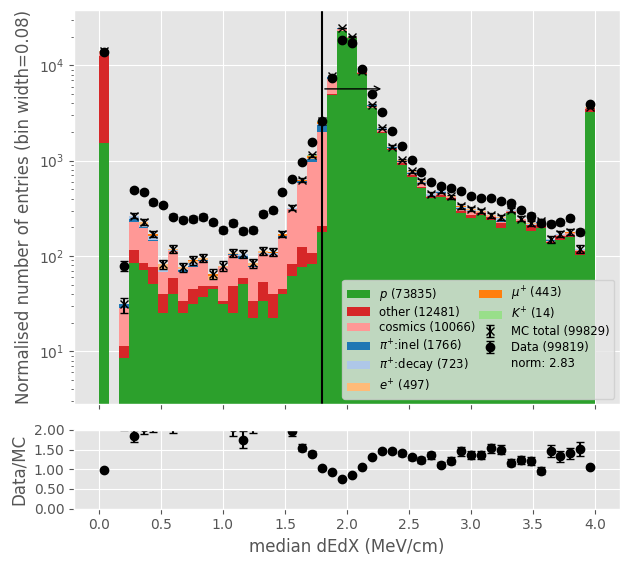

In [28]:
Plots.PlotTagged(proton_sample["mc"].recoParticles.beam_endPos_SCE.z, Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.beam_endPos_SCE.z, x_range = [0, 700], y_scale = "linear", truncate = True, x_label = "end z (cm)", norm = norm, bins = 50)



Plots.PlotTagged(cross_section.BeamParticleSelection.Median(proton_sample["mc"].recoParticles.beam_dEdX), Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = cross_section.BeamParticleSelection.Median(proton_sample["data"].recoParticles.beam_dEdX), x_range = [0, 4], y_scale = "log", truncate = True, x_label = "median dEdX (MeV/cm)", norm = norm, bins = 50)
Plots.DrawMultiCutPosition(1.8, face = ">", arrow_length = 0.5)

In [29]:
proton_mask = {k : cross_section.BeamParticleSelection.Median(v.recoParticles.beam_dEdX) > 1.9 for k, v in proton_sample.items()}
proton_sample  = {k : v.Filter([proton_mask[k]],[proton_mask[k]], returnCopy = True) for k, v in proton_sample.items()}


f=<Array [True, False, True, True, ..., True, True, True] type='35313 * bool'>
f=<Array [True, True, True, True, ..., True, True, True] type='99819 * bool'>


In [ ]:
proton_mask = {k : cross_section.BeamParticleSelection.HasFinalStatePFOsCut(v) for k, v in proton_sample.items()}
proton_sample = {k : v.Filter([proton_mask[k]], [proton_mask[k]], returnCopy = True) for k, v in proton_sample.items()}

proton_sample = {k : v.Filter([cross_section.PFOSelection.GoodShowerSelection(v)], returnCopy = True) for k, v in proton_sample.items()}

In [ ]:
proton_sample["mc"].recoParticles.LoadData("beam_track_score", "reco_beam_PFP_trackScore", False)
proton_sample["data"].recoParticles.LoadData("beam_track_score", "reco_beam_PFP_trackScore", False)

In [ ]:
with Plots.PlotBook("1GeV_proton_sideband.pdf", True) as book:
    Plots.PlotTags(Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), xlabel = "proton sideband")
    book.Save()
    Plots.PlotBar(ak.num(proton_sample["mc"].recoParticles.number), xlabel = "number of PFOs")
    book.Save()
    Plots.PlotBar(ak.num(proton_sample["data"].recoParticles.number), xlabel = "number of PFOs")
    book.Save()
    Plots.PlotTagged(proton_sample["mc"].recoParticles.track_score, Tags.GenerateTrueParticleTagsPiPlus(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles.track_score, x_range = [0, 1], bins = 50, norm = True, x_label = "track score")
    book.Save()
    Plots.PlotHistDataMC(ak.mean(proton_sample["data"].recoParticles.track_score, axis = -1), ak.mean(proton_sample["mc"].recoParticles.track_score, axis = -1), x_range = [0, 1], bins = 21, norm = True, xlabel = "mean track score")
    book.Save()
    Plots.PlotTagged(proton_sample["mc"].recoParticles._RecoParticleData__beam_track_score, Tags.GenerateTrueBeamParticleTags(proton_sample["mc"]), data2 = proton_sample["data"].recoParticles._RecoParticleData__beam_track_score, norm = True, bins = 50, x_label = "beam particle track score")
    book.Save()